In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# ====== Dataset ======
X = np.array([
    [1, 7], [2, 8], [3, 8],       # Class +1
    [5, 1], [6, -1], [7, 3], [5, -2]  # Class -1
])
y = np.array([1, 1, 1, -1, -1, -1, -1])

def point_distance(x, w, b):
    return abs(np.dot(w, x) + b) / np.linalg.norm(w)

def project_onto_hyperplane(x, w, b):
    """Project a point x onto the hyperplane defined by w·x + b = 0"""
    w_norm_sq = np.dot(w, w)
    return x - ((np.dot(w, x) + b) / w_norm_sq) * w

def plot_margin(w0=1.0, w1=-1.0, b=-1.0):
    w = np.array([w0, w1])
    norm_w = np.linalg.norm(w)

    distances = np.array([point_distance(xi, w, b) for xi in X])
    margin = np.min(distances)
    support_indices = np.where(distances == margin)[0]
    support_vectors = X[support_indices]

    plt.figure(figsize=(8, 6))
    colors = ['blue' if label == 1 else 'red' for label in y]
    plt.scatter(X[:, 0], X[:, 1], c=colors, s=80, edgecolors='k', label='Data Points')

    ax = plt.gca()
    xlim = ax.get_xlim()
    xx = np.linspace(*xlim, 100)

    if w1 != 0:
        yy = -(w0 * xx + b) / w1
        plt.plot(xx, yy, 'k-', label='Decision Boundary')

        yy_plus = -(w0 * xx + b + margin * norm_w) / w1
        yy_minus = -(w0 * xx + b - margin * norm_w) / w1
        plt.plot(xx, yy_plus, 'k--', label='Margins')
        plt.plot(xx, yy_minus, 'k--')
    else:
        x_val = -b / w0
        plt.axvline(x_val, color='k')
        plt.axvline(x_val + margin, color='k', linestyle='--')
        plt.axvline(x_val - margin, color='k', linestyle='--')

    plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=150,
                facecolors='none', edgecolors='black', linewidths=2, label='Support Vectors')

    # Draw perpendicular lines from support vector to hyperplane
    for sv in support_vectors:
        proj = project_onto_hyperplane(sv, w, b)
        plt.plot([sv[0], proj[0]], [sv[1], proj[1]], 'g--')
        plt.text(*sv, f'{point_distance(sv, w, b):.2f}', fontsize=9, ha='right', color='green')

    plt.title(f"Interactive SVM | Margin = {margin:.2f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.legend()
    plt.axis([0, 8, -4, 10])
    plt.show()

interact(plot_margin,
         w0=FloatSlider(value=1, min=-5, max=5, step=0.2, description='w0'),
         w1=FloatSlider(value=-1, min=-5, max=5, step=0.2, description='w1'),
         b=FloatSlider(value=-1, min=-10, max=10, step=0.5, description='b'))

# w0 = 2
# w1 = -2.2
# b = 2

interactive(children=(FloatSlider(value=1.0, description='w0', max=5.0, min=-5.0, step=0.2), FloatSlider(value…

<function __main__.plot_margin(w0=1.0, w1=-1.0, b=-1.0)>

# SVM
## Hard margin


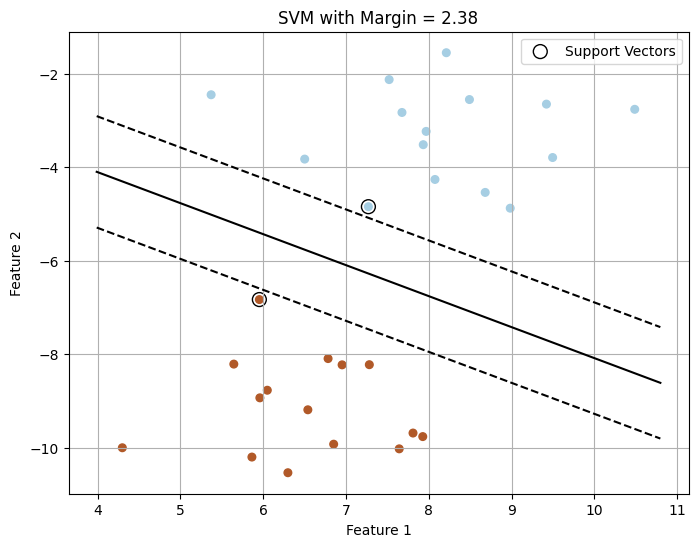

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

# Create a simple 2-class dataset
X, y = make_blobs(n_samples=30, centers=2, random_state=6)

# Fit a linear SVM
clf = SVC(kernel='linear', C=1.0)
clf.fit(X, y)

# Get weights and bias
w = clf.coef_[0]
b = clf.intercept_[0]

# Calculate the margin
margin = 2 / np.linalg.norm(w)

# Plotting
plt.figure(figsize=(8, 6))

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)

# Plot support vectors
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='k', label='Support Vectors')

# Create a grid to plot the decision boundary and margins
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1])
yy = -(w[0] * xx + b) / w[1]  # Decision boundary
yy_margin_up = yy + margin / 2
yy_margin_down = yy - margin / 2

# Plot decision boundary and margins
plt.plot(xx, yy, 'k-')
plt.plot(xx, yy_margin_up, 'k--')
plt.plot(xx, yy_margin_down, 'k--')

plt.title(f'SVM with Margin = {margin:.2f}')
plt.legend()
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()


## Soft margin
Following interacts user as they changes value of C. 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs
from ipywidgets import interact, FloatLogSlider
import warnings

warnings.filterwarnings("ignore", category=UserWarning)  # for clean widget output

# Create a 2-class dataset
X, y = make_blobs(n_samples=50, centers=2, random_state=6)

def plot_svm(C=1.0):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X, y)

    w = clf.coef_[0]
    b = clf.intercept_[0]
    margin = 2 / np.linalg.norm(w)

    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)
    plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
                s=100, facecolors='none', edgecolors='k', label='Support Vectors')

    ax = plt.gca()
    xlim = ax.get_xlim()
    xx = np.linspace(xlim[0], xlim[1])
    yy = -(w[0] * xx + b) / w[1]
    yy_margin_up = yy + margin / 2
    yy_margin_down = yy - margin / 2

    plt.plot(xx, yy, 'k-', label='Decision Boundary')
    plt.plot(xx, yy_margin_up, 'k--', label='Margins')
    plt.plot(xx, yy_margin_down, 'k--')
    plt.title(f'SVM with C={C} | Margin={margin:.2f}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)
    plt.legend()
    plt.show()

# Create slider for log-scale C
interact(plot_svm,
         C=FloatLogSlider(value=1.0, base=10, min=-2, max=2, step=0.1,
                          description='C Value:', continuous_update=False))


interactive(children=(FloatLogSlider(value=1.0, continuous_update=False, description='C Value:', max=2.0, min=…

<function __main__.plot_svm(C=1.0)>

## Following allows you to change the slope, intercept, etc of the line

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from ipywidgets import interact, FloatSlider
import warnings

warnings.filterwarnings("ignore")

# Generate synthetic dataset
X, y = make_blobs(n_samples=40, centers=2, random_state=6)

def plot_manual_svm(w0=1.0, w1=1.0, b=0.0):
    w = np.array([w0, w1])
    norm_w = np.linalg.norm(w)
    margin = 2 / norm_w if norm_w != 0 else 0

    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired)

    ax = plt.gca()
    xlim = ax.get_xlim()
    xx = np.linspace(xlim[0], xlim[1])
    
    # Hyperplane: w0*x + w1*y + b = 0 → y = -(w0*x + b)/w1
    if w1 != 0:
        yy = -(w0 * xx + b) / w1
        yy_up = yy + margin / 2
        yy_down = yy - margin / 2

        plt.plot(xx, yy, 'k-', label='Hyperplane')
        plt.plot(xx, yy_up, 'k--', label='Margins')
        plt.plot(xx, yy_down, 'k--')

        plt.title(f'Manual Hyperplane | Margin = {margin:.2f}')
    else:
        plt.axvline(x=-b / w0, color='k', label='Vertical Hyperplane')
        plt.title(f'Manual Hyperplane (vertical) | Margin = {margin:.2f}')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)
    plt.legend()
    plt.show()

interact(plot_manual_svm,
         w0=FloatSlider(min=-5, max=5, step=0.1, value=1.0, description='w0'),
         w1=FloatSlider(min=-5, max=5, step=0.1, value=1.0, description='w1'),
         b=FloatSlider(min=-10, max=10, step=0.5, value=0.0, description='b'))


interactive(children=(FloatSlider(value=1.0, description='w0', max=5.0, min=-5.0), FloatSlider(value=1.0, desc…

<function __main__.plot_manual_svm(w0=1.0, w1=1.0, b=0.0)>